# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense



In [57]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

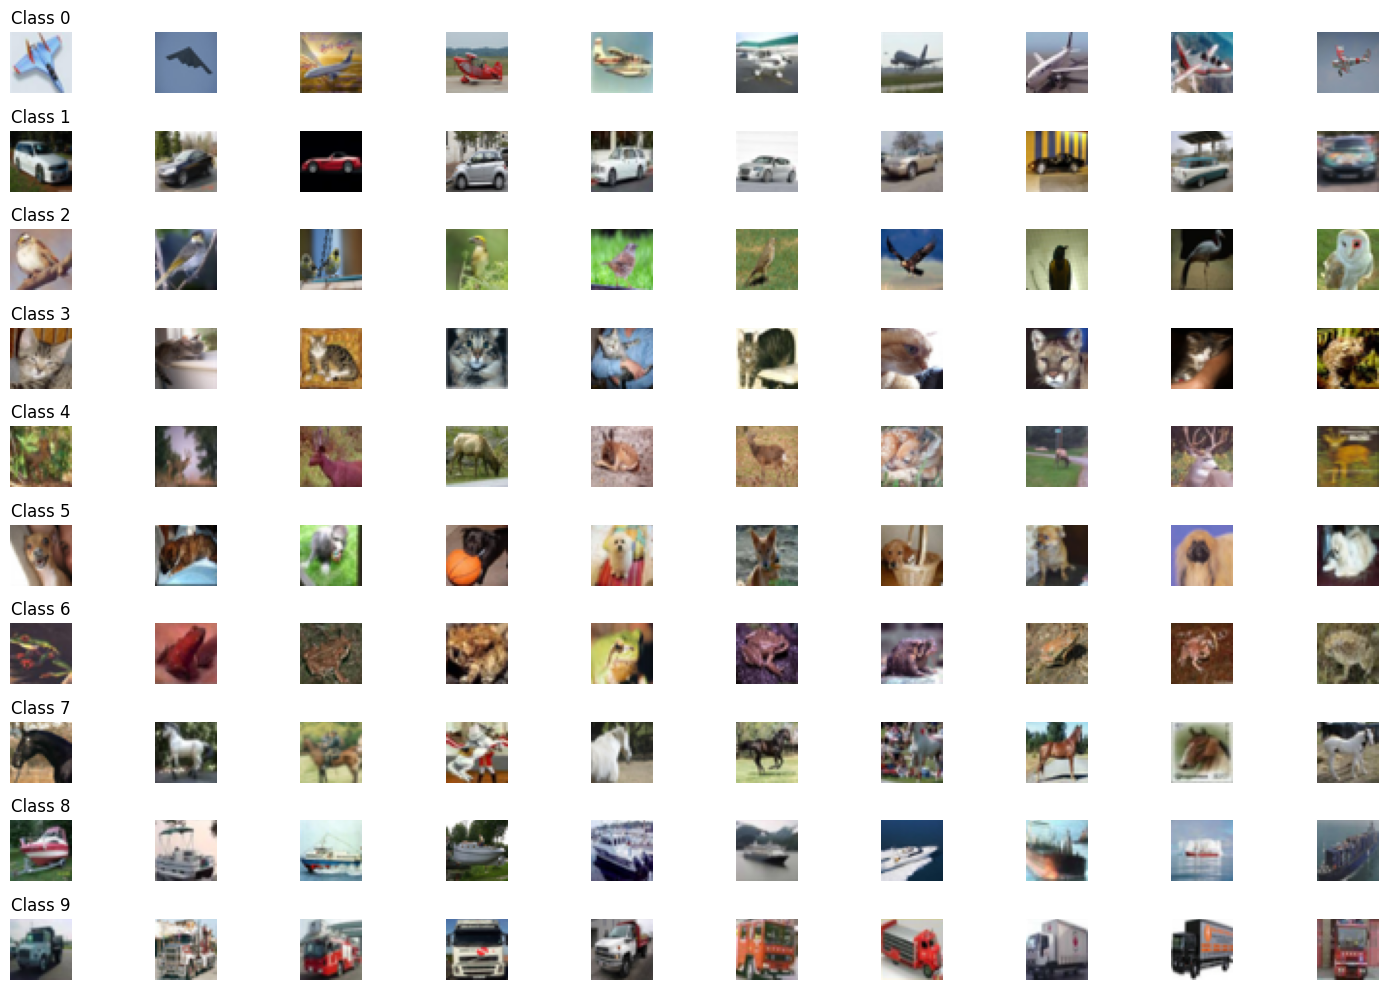

In [58]:
# show rand 10 smamples images for each class
classes = np.unique(y_train)
num_classes = len(classes)
plt.figure(figsize=(15, 10))
for cls in classes:
    idxs = np.where(y_train == cls)[0]
    selected_idxs = np.random.choice(idxs, 10, replace=False)
    for i, idx in enumerate(selected_idxs):
        plt.subplot(num_classes, 10, cls * 10 + i + 1)
        plt.imshow(x_train[idx])
        plt.axis('off')
        if i == 0:
            plt.title(f'Class {cls}')
plt.tight_layout()
plt.show()

In [59]:
# Convert the labels to one-hot encoded form.
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [60]:
 # Normalize athe images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [47]:
x_train.shape

(50000, 32, 32, 3)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [5]:
from keras.backend import clear_session
clear_session()

In [ ]:

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))


/Users/smithn5/ironhack/labs/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=120, batch_size=512, validation_split=0.2)
    

Epoch 1/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.1565 - loss: 2.2565 - val_accuracy: 0.1817 - val_loss: 2.2072
Epoch 2/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.2251 - loss: 2.1540 - val_accuracy: 0.1903 - val_loss: 2.1247
Epoch 3/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.2689 - loss: 2.0522 - val_accuracy: 0.2756 - val_loss: 2.0187
Epoch 4/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.3035 - loss: 1.9798 - val_accuracy: 0.2912 - val_loss: 1.9888
Epoch 5/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.3232 - loss: 1.9333 - val_accuracy: 0.3218 - val_loss: 1.9319
Epoch 6/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.3365 - loss: 1.8966 - val_accuracy: 0.3090 - val_loss: 1.9170
Epoch 7/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.3425 - loss: 1.8722 - val_accuracy: 0.3248 - val_loss: 1.9182
Epoch 8/120
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.3555 - loss: 1.8484 - val_accurac

*   Plot the cross entropy loss curve and the accuracy curve

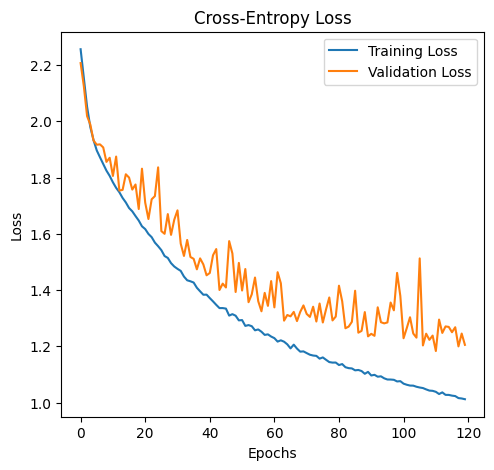

In [9]:
# Your code here :s.
history = model.history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [10]:
from keras.backend import clear_session
clear_session()

In [11]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))


*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [12]:
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy', 'f1_score'])
model.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.1714 - f1_score: 0.1487 - loss: 2.2623 - val_accuracy: 0.1720 - val_f1_score: 0.1025 - val_loss: 2.2272
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 332ms/step - accuracy: 0.2581 - f1_score: 0.2328 - loss: 2.1309 - val_accuracy: 0.2029 - val_f1_score: 0.1572 - val_loss: 2.1379
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 290ms/step - accuracy: 0.2886 - f1_score: 0.2730 - loss: 2.0194 - val_accuracy: 0.1499 - val_f1_score: 0.0942 - val_loss: 2.4427
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 277ms/step - accuracy: 0.3164 - f1_score: 0.3022 - loss: 1.9554 - val_accuracy: 0.2834 - val_f1_score: 0.2274 - val_loss: 1.9799
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 270ms/step - accuracy: 0.3379 - f1_score: 0.3254 - loss: 1.8957 - val_accuracy: 0.2949 - val_f1_score: 0.2619 - val_loss: 1.9572
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 291ms/step - accuracy: 0.3548 - f1_score: 0.3435 - loss: 1.8484 - val_accuracy: 0.2594 - val_f1_score: 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

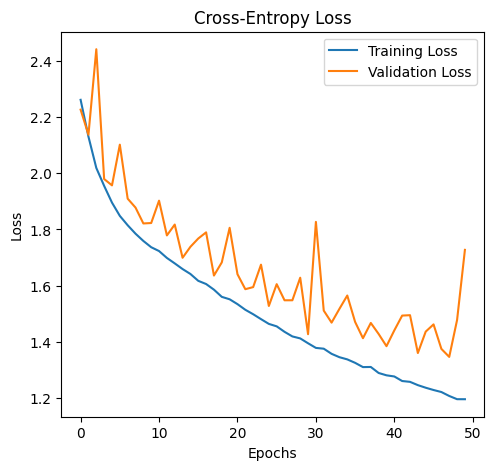

In [13]:
# Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
# Your code here :s.
history = model.history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()



**Comment on the observation**

*(Double-click or enter to edit)*

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


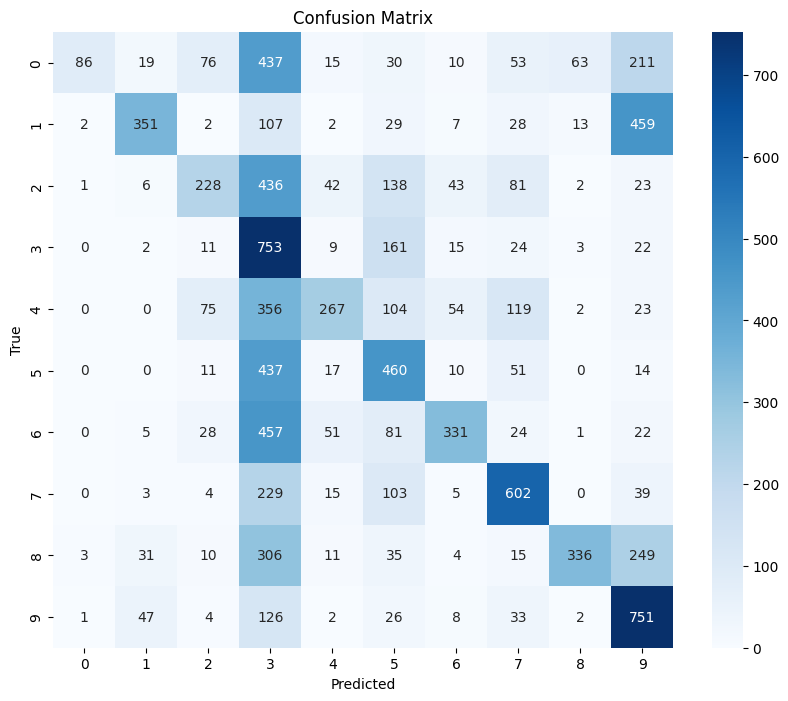

In [14]:
# Use predict function to predict the output for the test split
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
# Plot the confusion matrix for the new model and comment on the class confusions.
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Comment here :**

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [15]:
# print the test accuracy for trainded model
model.evaluate(x_test, y_test)





313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4165 - f1_score: 0.4118 - loss: 1.7139


[1.7138923406600952,
 0.4165000021457672,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.15736504, 0.47950816, 0.31469974, 0.32428935, 0.37316558,
        0.42455003, 0.4451916 , 0.5931034 , 0.47257376, 0.53394943],
       dtype=float32)>]

## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [2]:
from keras.backend import clear_session
clear_session()

In [8]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# find number of classes
classes = np.unique(y_train)
num_classes = len(classes)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
 # Normalize athe images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# change the image size to 64x64
x_train_exploded = np.array([cv2.resize(img, (64, 64)) for img in x_train])
x_test_exploded = np.array([cv2.resize(img, (64, 64)) for img in x_test])

In [9]:
model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

/Users/smithn5/ironhack/labs/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [10]:
x_train_exploded.shape, x_test_exploded.shape

((50000, 64, 64, 3), (10000, 64, 64, 3))

In [11]:
model.fit(x_train_exploded, y_train, epochs=10, batch_size=512, validation_split=0.2)




Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 629s 8s/step - accuracy: 0.1195 - loss: 2.3010 - val_accuracy: 0.1150 - val_loss: 2.2995
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.1223 - loss: 2.2983 - val_accuracy: 0.1691 - val_loss: 2.2965
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 586s 7s/step - accuracy: 0.1617 - loss: 2.2940 - val_accuracy: 0.1793 - val_loss: 2.2897
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 559s 7s/step - accuracy: 0.1785 - loss: 2.2822 - val_accuracy: 0.2210 - val_loss: 2.2693
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 571s 7s/step - accuracy: 0.2163 - loss: 2.2350 - val_accuracy: 0.2107 - val_loss: 2.1834
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 579s 7s/step - accuracy: 0.2320 - loss: 2.1416 - val_accuracy: 0.1451 - val_loss: 2.2995
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 583s 7s/step - accuracy: 0.2673 - loss: 2.0716 - val_accuracy: 0.2437 - val_loss: 2.1878
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 560s 7s/step - accuracy: 0.2927 - loss: 2.0057 - val_accuracy: 0.2938 - v

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step


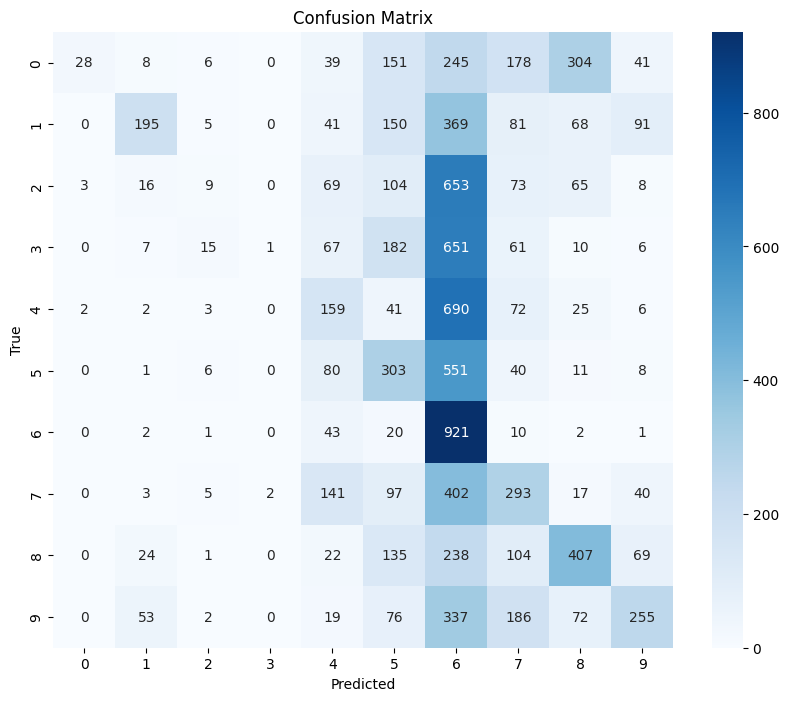

In [13]:
# Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.
y_pred = model.predict(x_test_exploded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
# Plot the confusion matrix for the new model and comment on the class confusions.
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
to introduce non-linearity into the model, enabling it to learn complex patterns and relationships in the data.


_

2 - Key Differences between sigmoid and softmax:
- Sigmoid function outputs a single probability value between 0 and 1, making it suitable for binary classification.
- Softmax function outputs a probability distribution across multiple classes, ensuring that the sum of probabilities equals 1, making it suitable for multi-class classification.



_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
- Categorical crossentropy is used for multi-class classification problems where each class is mutually exclusive, while binary crossentropy is used for binary classification problems with two classes.


_
